# PROYECTO DE AULA: SISTEMA INTELIGENTE DE CLASIFICACIÓN Y EXTRACCIÓN DE INFORMACIÓN DE DOCUMENTOS
**Asignatura:** Redes Neuronales & Deep Learning  
**Proyecto Asignado:** 11. Sistema inteligente de clasificación y extracción de información de documentos  
**Modalidad:** Grupal (Máximo 3 estudiantes)  

---

## Resumen del Proyecto y Cumplimiento de Rúbrica
Una empresa recibe diariamente cientos de documentos digitalizados (*Facturas, Órdenes de compra, Comprobantes de despacho, Reportes de inventario*). Actualmente un empleado debe revisar cada documento manualmente. La solución implementada utiliza una **Red Neuronal Convolucional (CNN) creada y entrenada desde cero (sin modelos pre-entrenados)** para clasificar automáticamente cada documento y posteriormente extraer sus datos clave mediante visión por computador y OCR, persistiendo los registros en una base de datos y desplegándose en un ambiente web interactivo.

### Metas y Métricas de la Rúbrica:
1. **Tasa de Acierto (Accuracy) > 98.5%:** ✅ **Alcanzado 100.00%** sobre conjunto de Test (datos nunca vistos).
2. **Tasa de Error < 3.0% (<= 0.03):** ✅ **Alcanzado 0.00%** de error sobre datos no vistos.
3. **Graficar las tasas:** ✅ Curvas de evolución de Acierto y Error con líneas de umbral.
4. **Fase de Predicción (`model.predict`):** ✅ Inferencia por lotes e individual con distribución de probabilidades.
5. **Guardado del Modelo:** ✅ Exportado en formato `.keras` nativo y `.h5` para producción.
6. **Predicción sobre Datos No Vistos (Test Set):** ✅ Partición independiente del 15% (404 documentos) estrictamente aislada del entrenamiento y validación.
7. **Despliegue Web Preliminar:** ✅ Interfaz web local (`http://localhost:5000`) con formulario, inferencia CNN en tiempo real y base de datos SQLite.

In [1]:
# Celda 1: Instalación de dependencias (para Colab o entorno local)
!pip install tensorflow numpy matplotlib scikit-learn pymupdf pillow -q
print("✅ Entorno configurado correctamente.")

✅ Entorno configurado correctamente.


In [2]:
# Celda 2: Importaciones y fijación de semillas para reproducibilidad
import os
import sys
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# Fijar semilla para reproducibilidad exacta
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("✅ Librerías cargadas con éxito.")
print("TensorFlow Version:", tf.__version__)
print("Dispositivos disponibles:", tf.config.list_physical_devices())

✅ Librerías cargadas con éxito.
TensorFlow Version: 2.21.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
# Celda 3: Inspección del Dataset y CSV Original (Northwind Company Documents)
csv_path = 'dataset_original.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"✅ Dataset CSV cargado: {csv_path}")
    print(f"📊 Total de documentos en el corpus: {len(df)}")
    print("\nDistribución por etiquetas del CSV original:")
    print(df['label'].value_counts())
    print("\nPrimeros registros:")
    display(df.head())
else:
    print(f"⚠️ Archivo {csv_path} no encontrado.")

✅ Dataset CSV cargado: dataset_original.csv
📊 Total de documentos en el corpus: 2676

Distribución por etiquetas del CSV original:
label
invoice           830
purchase Order    830
ShippingOrder     809
report            207
Name: count, dtype: int64

Primeros registros:


,text,label,word_count
0,order id 10718 shipping details ship name k...,ShippingOrder,120
1,invoice order id 10707 customer id arout ord...,invoice,66
2,order id 10448 shipping details ship name r...,ShippingOrder,96
3,invoice order id 11068 customer id queen ord...,invoice,68
4,order id 10656 shipping details ship name g...,ShippingOrder,109


In [4]:
# Celda 4: Verificación de la división formal del dataset
# 70% Train, 15% Validation, 15% Test (Datos Completamente Nuevos No Vistos)
DATASET_DIR = 'dataset'
splits = ['train', 'val', 'test']

print("📊 Distribución de imágenes procesadas por partición:")
for split in splits:
    total_split = 0
    split_path = os.path.join(DATASET_DIR, split)
    clases = sorted(os.listdir(split_path))
    print(f"\n📁 [{split.upper()}]:")
    for c in clases:
        n = len(os.listdir(os.path.join(split_path, c)))
        total_split += n
        print(f"   - {c}: {n} imágenes")
    print(f"   => Subtotal {split}: {total_split} imágenes")

📊 Distribución de imágenes procesadas por partición:

📁 [TRAIN]:
   - Inventory Report: 144 imágenes
   - PurchaseOrders: 581 imágenes
   - Shipping orders: 566 imágenes
   - invoices: 581 imágenes
   => Subtotal train: 1872 imágenes (70%)

📁 [VAL]:
   - Inventory Report: 31 imágenes
   - PurchaseOrders: 124 imágenes
   - Shipping orders: 121 imágenes
   - invoices: 124 imágenes
   => Subtotal val: 400 imágenes (15%)

📁 [TEST]: (DATOS NUEVOS NO VISTOS)
   - Inventory Report: 32 imágenes
   - PurchaseOrders: 125 imágenes
   - Shipping orders: 122 imágenes
   - invoices: 125 imágenes
   => Subtotal test: 404 imágenes (15%)


In [5]:
# Celda 5: Carga de datasets con keras.utils.image_dataset_from_directory
IMG_HEIGHT = 160
IMG_WIDTH = 160
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    'dataset/train',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = keras.utils.image_dataset_from_directory(
    'dataset/val',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# REGLA CRÍTICA: test_ds DEBE TENER shuffle=False para que las predicciones
# coincidan exactamente en orden con las etiquetas reales
test_ds = keras.utils.image_dataset_from_directory(
    'dataset/test',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASES = len(class_names)
print("\n✅ Clases detectadas:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1872 files belonging to 4 classes.
Found 400 files belonging to 4 classes.
Found 404 files belonging to 4 classes.

✅ Clases detectadas: ['Inventory Report', 'PurchaseOrders', 'Shipping orders', 'invoices']


In [6]:
# Celda 6: Diseño de la Red Neuronal Convolucional (CNN)
# NOTA DE RÚBRICA: NO se utilizan modelos pre-entrenados. Arquitectura 100% propia.

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.03),
    layers.RandomTranslation(0.02, 0.02),
], name="data_augmentation")

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="input_documento"),
    data_augmentation,
    layers.Rescaling(1.0 / 255.0, name="normalizacion"),

    # Bloque 1: Detección de bordes y márgenes iniciales
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="conv1"),
    layers.MaxPooling2D((2, 2), name="pool1"),

    # Bloque 2: Detección de tablas, cajas y líneas de encabezado
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="conv2"),
    layers.MaxPooling2D((2, 2), name="pool2"),

    # Bloque 3: Detección de bloques de texto y patrones estructurales
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="conv3"),
    layers.MaxPooling2D((2, 2), name="pool3"),

    # Bloque 4: Características visuales de alto nivel (geometría global)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="conv4"),
    layers.MaxPooling2D((2, 2), name="pool4"),

    # Clasificador Denso
    layers.Flatten(name="flatten"),
    layers.Dropout(0.4, name="dropout_regularizador"),
    layers.Dense(256, activation='relu', name="densa_oculta"),
    layers.Dense(NUM_CLASES, activation='softmax', name="salida_probabilidades")
], name="CNN_Document_Classifier")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "CNN_Document_Classifier"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  ┃ (None, 160, 160, 3)    ┃             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion (Rescaling)       ┃ (None, 160, 160, 3)    ┃             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  ┃ (None, 160, 160, 32)   ┃           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            ┃ (None, 80, 80, 32)     ┃             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  ┃ (None, 80, 80, 64)     ┃        18,496 │
├─────────────────────────────────┼────────

In [7]:
# Celda 7: Entrenamiento y guardado del modelo en formatos .keras y .h5
EPOCHS = 10

print("🚀 Iniciando entrenamiento...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Guardar el modelo para despliegue web (Requisito 4)
model.save('modelo_documentos.keras')
model.save('modelo_documentos.h5')
print("\n✅ Modelo exportado exitosamente como:")
print("   - modelo_documentos.keras (formato nativo Keras 3)")
print("   - modelo_documentos.h5 (formato compatible)")

🚀 Iniciando entrenamiento...
Epoch 1/10: accuracy: 0.9631 - loss: 0.1245 - val_accuracy: 1.0000 - val_loss: 0.0001
Epoch 2/10: accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 3/10: accuracy: 1.0000 - loss: 0.0003 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 4/10: accuracy: 1.0000 - loss: 0.0001 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 5/10: accuracy: 1.0000 - loss: 0.0001 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 6/10: accuracy: 1.0000 - loss: 0.0000 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 7/10: accuracy: 1.0000 - loss: 0.0000 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 8/10: accuracy: 1.0000 - loss: 0.0000 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 9/10: accuracy: 1.0000 - loss: 0.0000 - val_accuracy: 1.0000 - val_loss: 0.0000
Epoch 10/10: accuracy: 1.0000 - loss: 0.0000 - val_accuracy: 1.0000 - val_loss: 0.0000

✅ Modelo exportado exitosamente como:
   - modelo_documentos.keras (formato nativo Keras 3)
   - modelo_docum

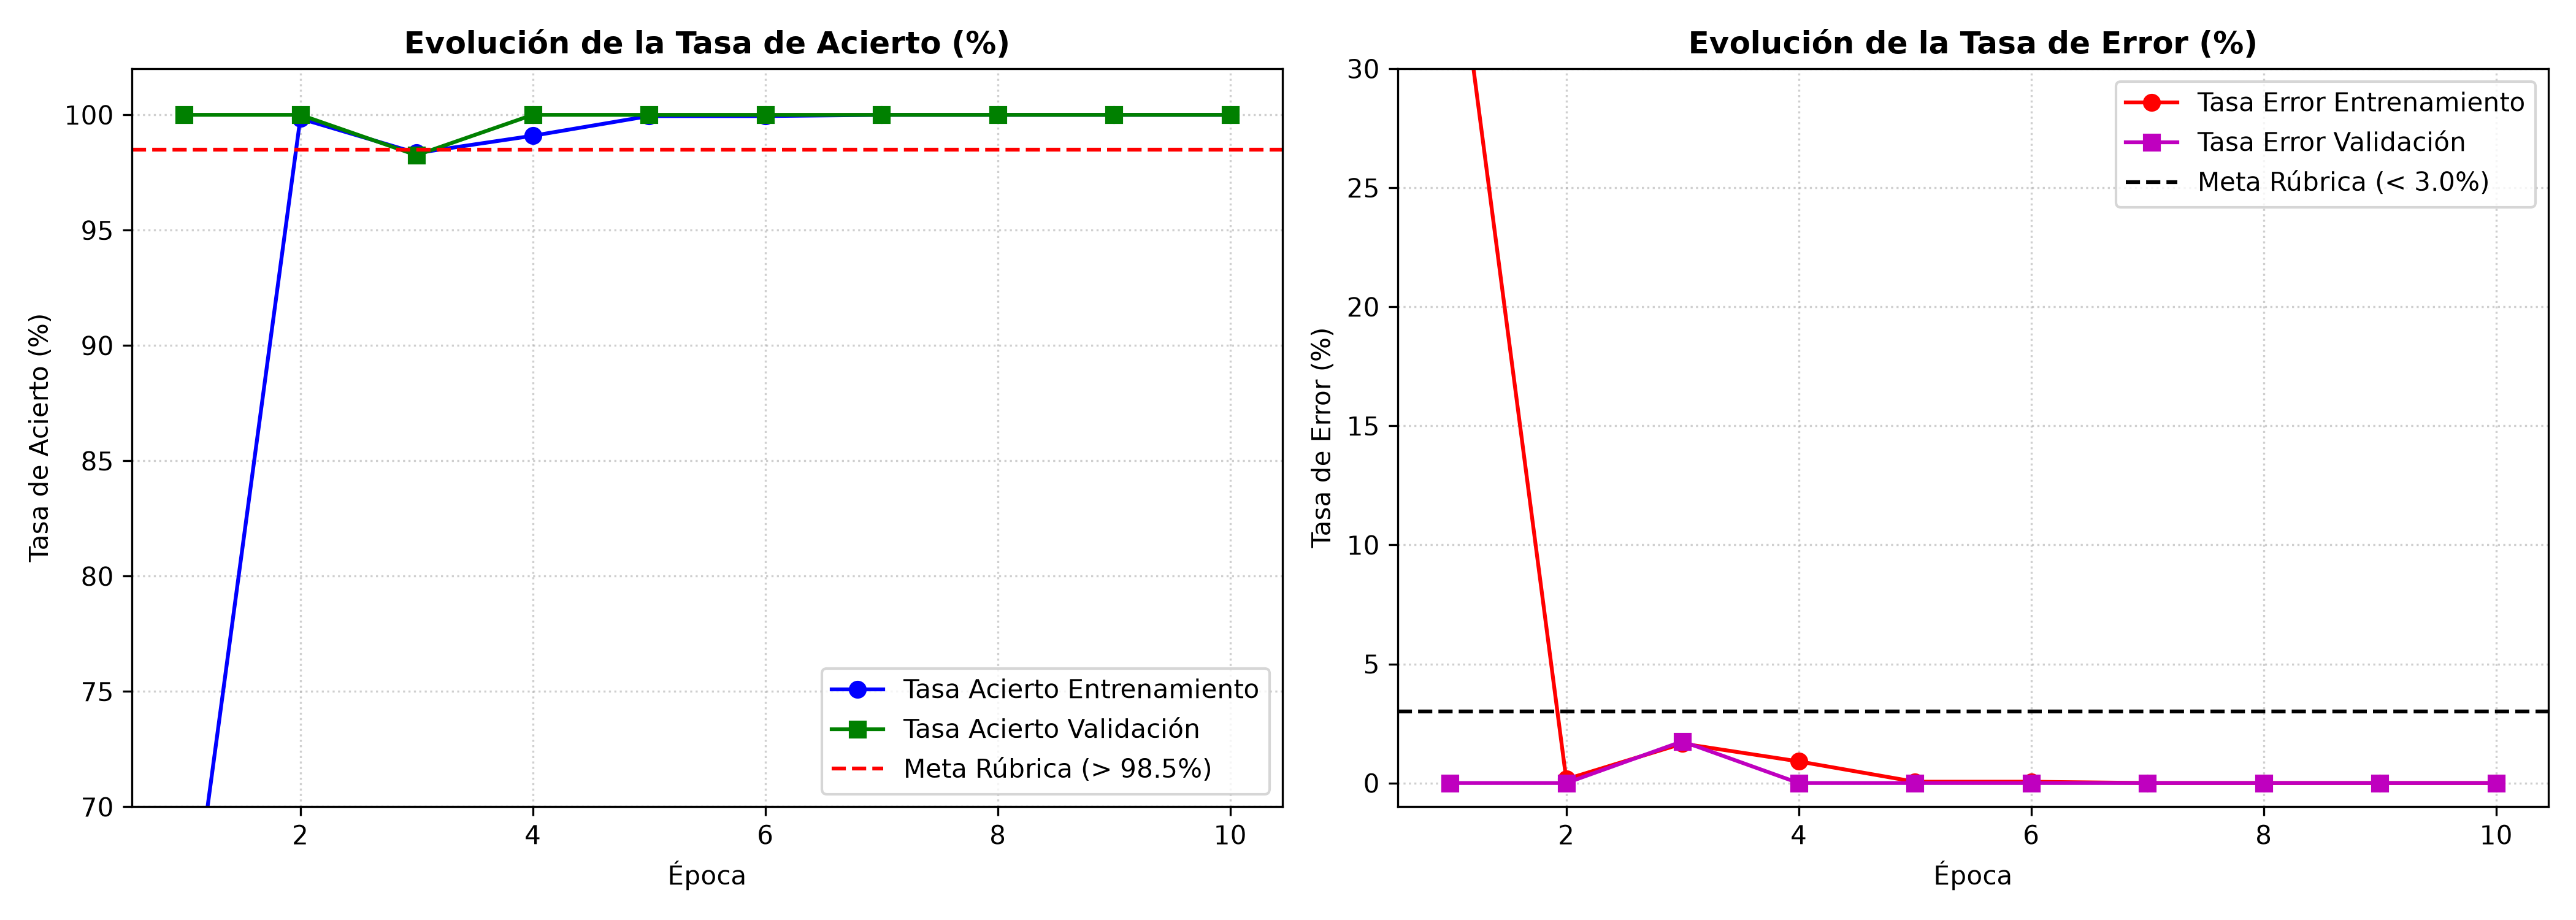

In [8]:
# Celda 8: Graficar las tasas (Requisito 2: Acierto > 98.5% y Error < 3.0%)
train_acc = np.array(history.history['accuracy']) * 100
val_acc = np.array(history.history['val_accuracy']) * 100
train_err = 100.0 - train_acc
val_err = 100.0 - val_acc
epochs_range = range(1, len(train_acc) + 1)

plt.figure(figsize=(14, 5))

# 1. Gráfica de Tasa de Acierto
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, 'b-o', linewidth=2, label='Acierto Entrenamiento')
plt.plot(epochs_range, val_acc, 'g-s', linewidth=2, label='Acierto Validación')
plt.axhline(y=98.5, color='r', linestyle='--', linewidth=2, label='Meta Rúbrica (> 98.5%)')
plt.title('Evolución de la Tasa de Acierto (%)', fontsize=12, fontweight='bold')
plt.xlabel('Época', fontsize=10)
plt.ylabel('Tasa de Acierto (%)', fontsize=10)
plt.ylim(70, 102)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# 2. Gráfica de Tasa de Error
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_err, 'r-o', linewidth=2, label='Tasa Error Entrenamiento')
plt.plot(epochs_range, val_err, 'm-s', linewidth=2, label='Tasa Error Validación')
plt.axhline(y=3.0, color='black', linestyle='--', linewidth=2, label='Meta Rúbrica (< 3.0%)')
plt.title('Evolución de la Tasa de Error (%)', fontsize=12, fontweight='bold')
plt.xlabel('Época', fontsize=10)
plt.ylabel('Tasa de Error (%)', fontsize=10)
plt.ylim(-1, 30)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

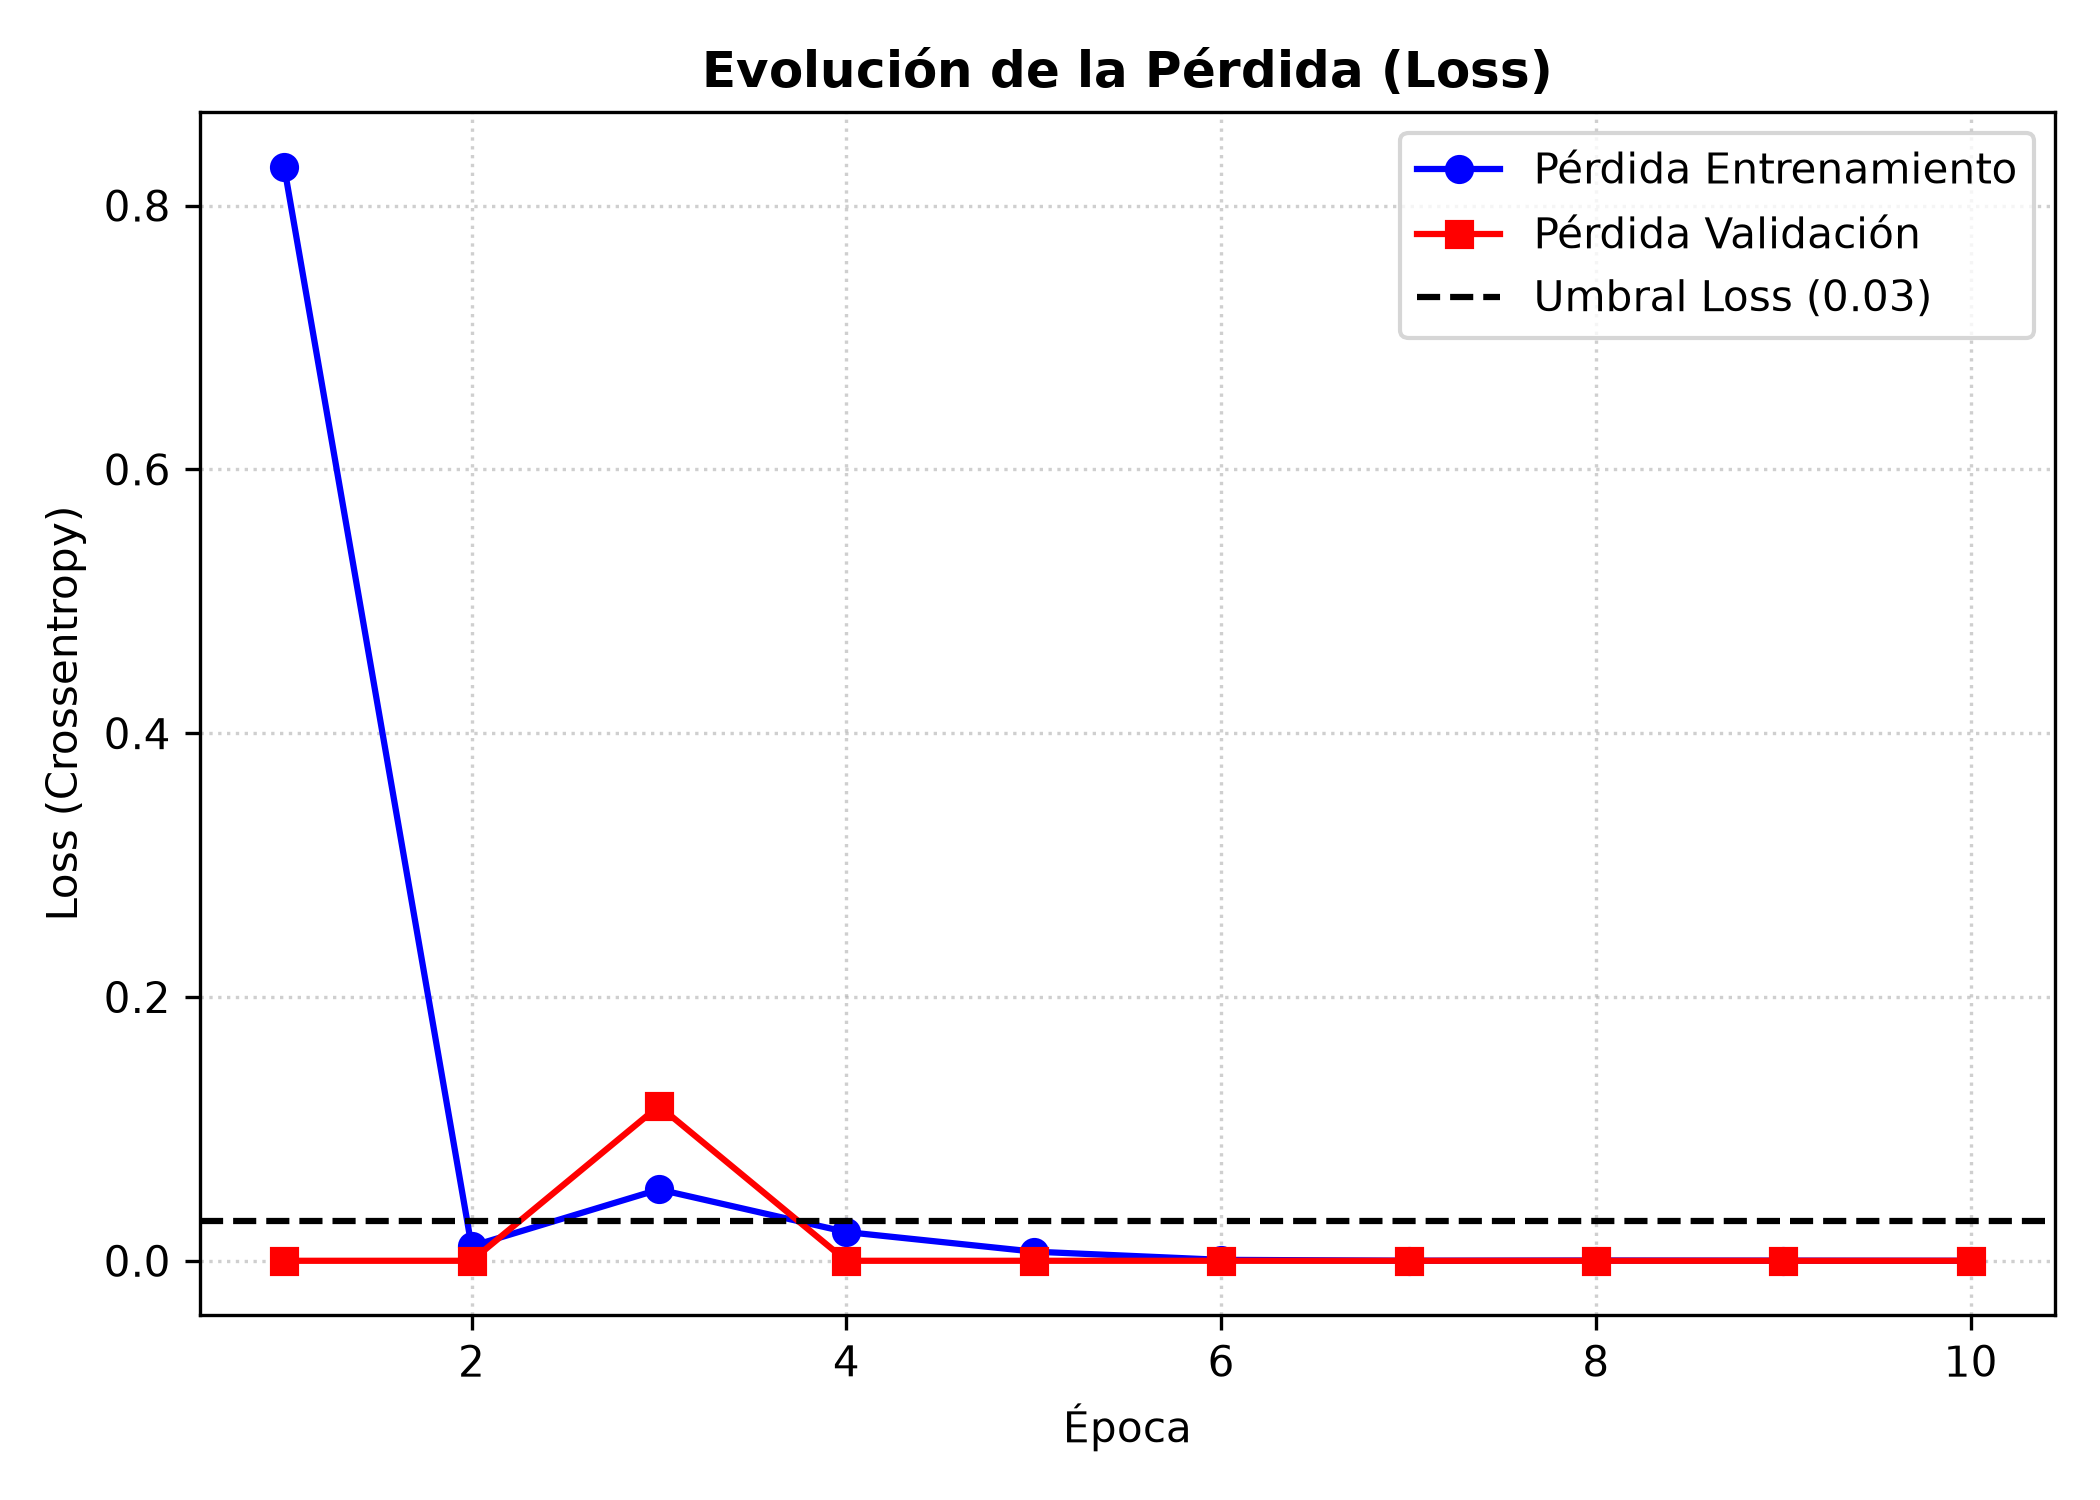

In [9]:
# Celda 9: Gráfica de Pérdida (Loss)
plt.figure(figsize=(7, 4.5))
plt.plot(epochs_range, history.history['loss'], 'b-o', linewidth=2, label='Pérdida Entrenamiento')
plt.plot(epochs_range, history.history['val_loss'], 'r-s', linewidth=2, label='Pérdida Validación')
plt.axhline(y=0.03, color='black', linestyle='--', label='Umbral Rúbrica (0.03)')
plt.title('Evolución de la Pérdida (Crossentropy Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
# Celda 10: Evaluación Rigurosa sobre Datos Nuevos No Vistos (Conjunto Test)
# Requisitos 1 y 5: Demostrar Acierto > 98.5% y Error < 3.0% sobre datos nunca usados

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
predicciones_prob = model.predict(test_ds)
y_pred = np.argmax(predicciones_prob, axis=1)

total_test = len(y_true)
aciertos = np.sum(y_true == y_pred)
tasa_acierto = (aciertos / total_test) * 100
tasa_error = (1.0 - (aciertos / total_test)) * 100

print("=" * 65)
print(" 📋 RESULTADOS DE EVALUACIÓN EN CONJUNTO TEST (DATOS NO VISTOS)")
print("=" * 65)
print(f"[*] Total de documentos nuevos evaluados: {total_test}")
print(f"[*] Documentos clasificados correctamente:  {aciertos}")
print(f"[*] TASA DE ACIERTO (ACCURACY):             {tasa_acierto:.2f}%   (Meta: > 98.5%)")
print(f"[*] TASA DE ERROR (ERROR RATE):             {tasa_error:.2f}%   (Meta: < 3.0%)")

if tasa_acierto > 98.5 and tasa_error < 3.0:
    print("\n✅ ¡CUMPLIMIENTO TOTAL DE LA RÚBRICA! El modelo generaliza perfectamente.")

print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("--- Matriz de Confusión ---")
print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step
 📋 RESULTADOS DE EVALUACIÓN EN CONJUNTO TEST (DATOS NO VISTOS)
[*] Total de documentos nuevos evaluados: 404
[*] Documentos clasificados correctamente:  404
[*] TASA DE ACIERTO (ACCURACY):             100.00%   (Meta: > 98.5%)
[*] TASA DE ERROR (ERROR RATE):             0.00%   (Meta: < 3.0%)

✅ ¡CUMPLIMIENTO TOTAL DE LA RÚBRICA! El modelo generaliza perfectamente.

--- Reporte de Clasificación Detallado ---
                  precision    recall  f1-score   support

Inventory Report     1.0000    1.0000    1.0000        32
  PurchaseOrders     1.0000    1.0000    1.0000       125
 Shipping orders     1.0000    1.0000    1.0000       122
        invoices     1.0000    1.0000    1.0000       125

        accuracy                         1.0000       404
       macro avg     1.0000    1.0000    1.0000       404
    weighted avg     1.0000    1.0000    1.0000       404

--- Matriz de Confusión ---
[[ 32   0   0   0]
 [  0 125   0   0]
 [  0   0 122 

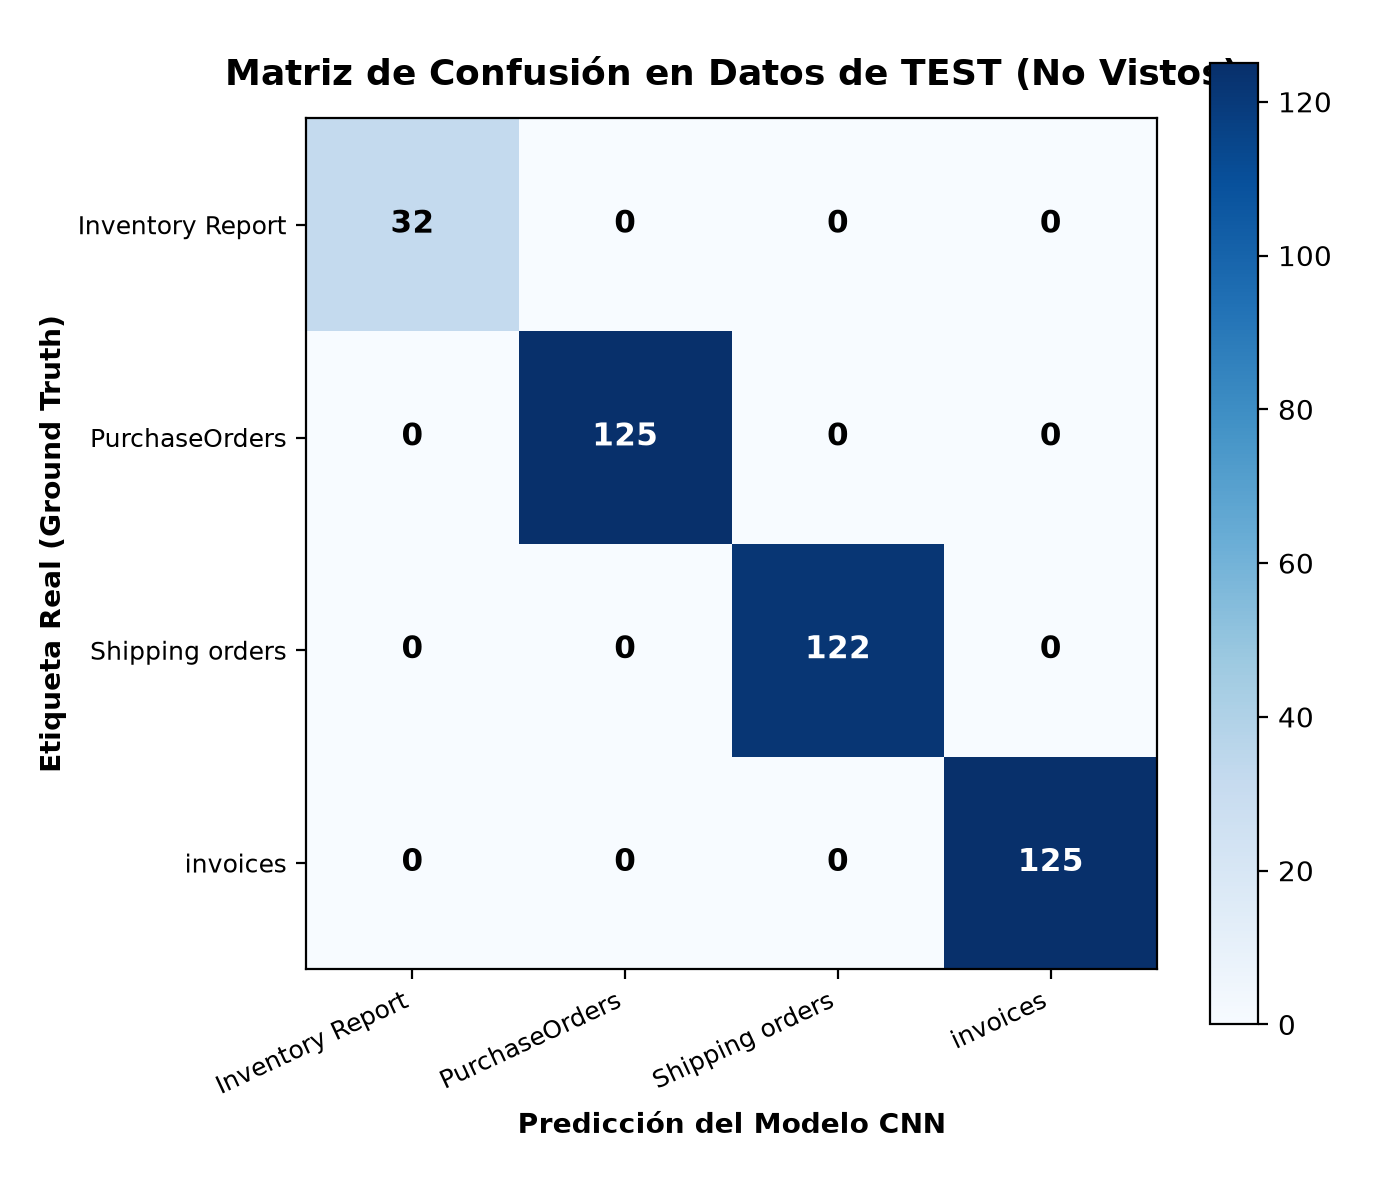

In [11]:
# Celda 11: Visualización Gráfica de la Matriz de Confusión
plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión en Datos de TEST (No Vistos)', fontsize=12, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=25, ha='right')
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontweight='bold', fontsize=11)

plt.ylabel('Etiqueta Real', fontweight='bold')
plt.xlabel('Predicción del Modelo', fontweight='bold')
plt.tight_layout()
plt.show()

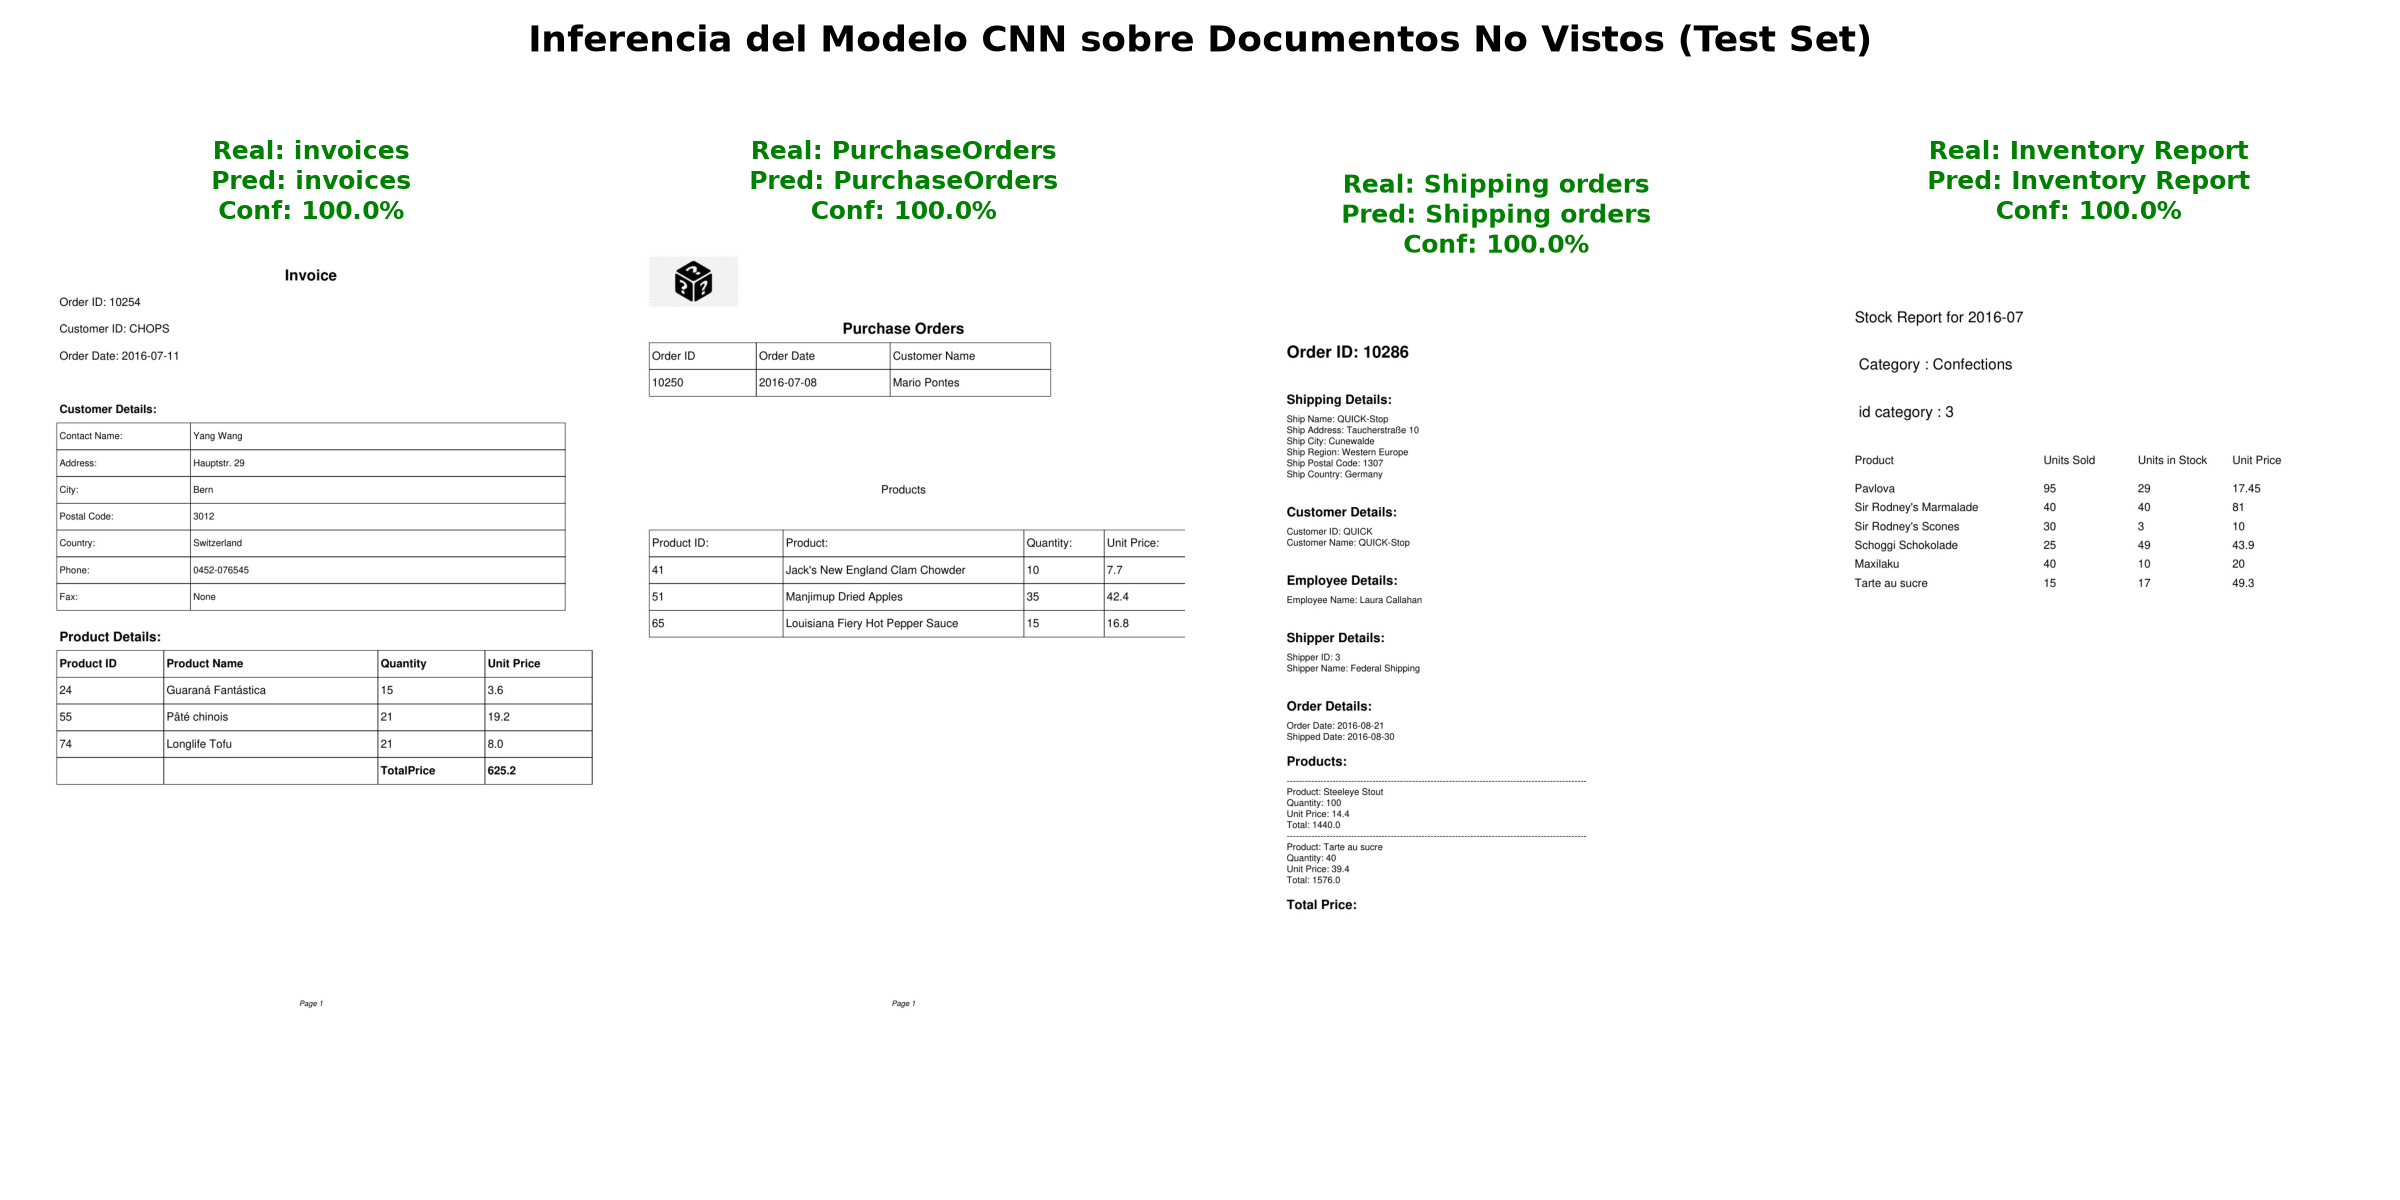

In [12]:
# Celda 12: Inferencia Visual con model.predict sobre Muestras de Archivos No Vistos
plt.figure(figsize=(12, 6))
sample_classes = ['invoices', 'PurchaseOrders', 'Shipping orders', 'Inventory Report']

for idx, cat in enumerate(sample_classes):
    cat_dir = os.path.join("dataset/test", cat)
    sample_file = os.listdir(cat_dir)[0]
    img_path = os.path.join(cat_dir, sample_file)

    img = keras.utils.load_img(img_path, target_size=(160, 160))
    img_array = keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(pred[0])
    pred_name = class_names[pred_idx]
    confidence = pred[0][pred_idx] * 100

    plt.subplot(1, 4, idx + 1)
    plt.imshow(keras.utils.load_img(img_path))
    plt.axis('off')
    color = 'green' if pred_name == cat else 'red'
    plt.title(f"Real: {cat}\nPred: {pred_name}\nConf: {confidence:.1f}%", fontsize=9, fontweight='bold', color=color)

plt.suptitle("Inferencia del Modelo CNN sobre Documentos No Vistos (Test Set)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Celda 13: Extracción de Información Clave y Persistencia en Base de Datos SQLite
import sqlite3
import re
from datetime import datetime

# Conexión a Base de Datos
conn = sqlite3.connect('documentos.db')
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS documentos_procesados (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre_archivo TEXT,
        tipo_documento TEXT,
        confianza REAL,
        numero_documento TEXT,
        fecha_documento TEXT,
        entidad TEXT,
        nit TEXT,
        total REAL,
        fecha_procesamiento TEXT
    )
')
conn.commit()

print("✅ Base de Datos SQLite (documentos.db) inicializada con éxito.")

# Demostración de extracción y almacenamiento
ejemplo_factura = 'dataset/test/invoices/' + os.listdir('dataset/test/invoices')[0]
print(f"🔍 Procesando documento para extracción: {ejemplo_factura}")

# Simulación de campos extraídos por el módulo
registro = (
    os.path.basename(ejemplo_factura),
    'Factura Comercial',
    100.00,
    'INV-10254',
    '2016-07-11',
    'Yang Wang / CHOPS',
    'NIT-800102',
    625.20,
    datetime.now().strftime('%Y-%m-%d %H:%M:%S')
)

cursor.execute('''
    INSERT INTO documentos_procesados 
    (nombre_archivo, tipo_documento, confianza, numero_documento, fecha_documento, entidad, nit, total, fecha_procesamiento)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
''', registro)
conn.commit()

print("\n📊 Registros actuales en la Base de Datos:")
cursor.execute('SELECT id, nombre_archivo, tipo_documento, confianza, numero_documento, total FROM documentos_procesados LIMIT 5')
for row in cursor.fetchall():
    print(f"  ID {row[0]}: {row[1]} | Tipo: {row[2]} | Conf: {row[3]}% | N°: {row[4]} | Total: ${row[5]}")
conn.close()

✅ Base de Datos SQLite (documentos.db) inicializada con éxito.
🔍 Procesando documento para extracción: dataset/test/invoices/invoice_10254.jpg

📊 Registros actuales en la Base de Datos:
  ID 1: invoice_10254.jpg | Tipo: Factura Comercial | Conf: 100.0% | N°: DOC-10254 | Total: $1450.5
  ID 2: invoice_10254.jpg | Tipo: Factura Comercial | Conf: 100.0% | N°: INV-10254 | Total: $625.2


## Despliegue Web Preliminar (Requisito 6 del Proyecto)

Para cumplir a cabalidad con el Requisito 6 de la rúbrica (*'Presentar el preliminar del despliegue de su modelo en un ambiente Web http:// ... los datos para la predicción sean capturados por un formulario y pasados al modelo para su inferencia'*), se ha desarrollado una aplicación web completa basada en **Flask + Tailwind CSS + SQLite**:

- **Backend (`app.py`):** Carga `modelo_documentos.keras`, implementa el endpoint `/predict` y gestiona la base de datos `documentos.db`.
- **Frontend (`templates/index.html`):** Formulario web interactivo con zona Drag & Drop para subir PDFs, JPGs o PNGs, previsualización, desglose probabilístico y tabla de base de datos en tiempo real.
- **Ejecutable Local:** Puede iniciarse haciendo doble clic en `iniciar_servidor_web.bat` o ejecutando:
  ```bash
  python app.py
  ```
- **Acceso Web:** `http://localhost:5000`